# Counting Labels & Weighted Loss Function

One way to avoid having class imbalance impact the loss function is to weight the losses of the different classes differently. To choose the weights, one needs to compute the class frequencies and divide it by the total number of images.

$$ w_n = \frac{\#Negative}{Total} ~~~~~ w_p = \frac{\#Positive}{Total}  $$

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

%matplotlib inline

In [13]:
# import dataset
MAIN_PATH = os.path.join("C:\\","Users","cmore","GitHub")
file_path = os.path.join(MAIN_PATH, "DL_Study", "Datasets", "nih", "train-small.csv")

train_df = pd.read_csv(file_path)
train_df.head()

,Image,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,PatientId,Pleural_Thickening,Pneumonia,Pneumothorax
0,00008270_015.png,0,0,0,0,0,0,0,0,0,0,0,8270,0,0,0
1,00029855_001.png,1,0,0,0,1,0,0,0,1,0,0,29855,0,0,0
2,00001297_000.png,0,0,0,0,0,0,0,0,0,0,0,1297,1,0,0
3,00012359_002.png,0,0,0,0,0,0,0,0,0,0,0,12359,0,0,0
4,00017951_001.png,0,0,0,0,0,0,0,0,1,0,0,17951,0,0,0


In [21]:
# Count up the number of instances of each class (drop non-class columns from the counts)
class_counts = train_df.drop(["Image", "PatientId"], axis=1).sum()
class_counts

Atelectasis           106
Cardiomegaly           20
Consolidation          33
Edema                  16
Effusion              128
Emphysema              13
Fibrosis               14
Hernia                  2
Infiltration          175
Mass                   45
Nodule                 54
Pleural_Thickening     21
Pneumonia              10
Pneumothorax           38
dtype: int64

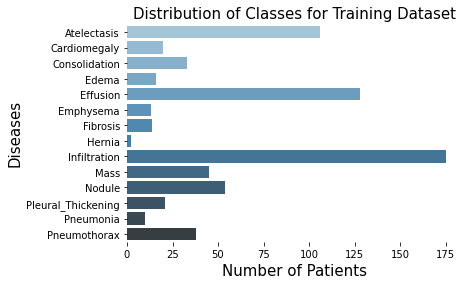

In [64]:
# Plot up the distribution of counts
ax = sns.barplot(x=class_counts.values, 
                 y=class_counts.index, data=class_counts,
                 palette="Blues_d", orient = 'h',order=class_counts.values  )
ax.set_yticklabels(class_counts.index)
plt.title('Distribution of Classes for Training Dataset', fontsize=15)
plt.xlabel('Number of Patients', fontsize=15)
plt.ylabel('Diseases', fontsize=15)
sns.despine(left=True, bottom=True)

## 1. Weighted Loss Fucntion

For this example, you'll first define a hypothetical set of true labels and then a set of predictions

In [65]:
# Generate an array of 4 binary label values, 3 positive and 1 negative
y_true = np.array(
        [[1],
         [1],
         [1],
         [0]])
print(f"y_true: \n{y_true}")

y_true: 
[[1]
 [1]
 [1]
 [0]]


### 1.1 Understanding Weighted Loss Function

#### 1.1.1 Two Models

To better understand the loss function, you will pretend that you have two models.
- Model 1 always outputs a 0.9 for any example that it's given.  
- Model 2 always outputs a 0.1 for any example that it's given.

In [66]:
# Make model predictions that are always 0.9 for all examples
y_pred_1 = 0.9 * np.ones(y_true.shape)
y_pred_2 = 0.1 * np.ones(y_true.shape)


### 1.2 Problems with the Regular Loss Function
The learning goal here is to notice that with a regular loss function (not a weighted loss), the model that always outputs 0.9 has a smaller loss (performs better) than model 2.
- This is because there is a class imbalance, where 3 out of the 4 labels are 1.
- If the data were perfectly balanced, (two labels were 1, and two labels were 0), model 1 and model 2 would have the same loss.  Each would get two examples correct and two examples incorrect.
- However, since the data is not balanced, the regular loss function implies that model 1 is better than model 2.

#### 1.2.1 Shortcomings of a Regular Non-weighted Loss

See what loss you get from these two models (model 1 always predicts 0.9, and model 2 always predicts 0.1), see what the regular (unweighted) loss function is for each model.